# v2-2. 검증 다시 하기
v1에서는 ```train_test_split```으로 거래를 무작위로 나눴음
그런데 같은 단지의 다른 호수 계약이 train/test 양쪽에 들어가면 모델은 "이미 본 건물"을 맞히는 문제를 풀게 됨
여기서는 **건물 단위**로 나눠서 처음 보는 건물을 얼마나 맞히는지 다시 봄

#### 이 노트북에서 하는 것
1. 같은 변수, 같은 XGBoost 설정으로 무작위 분할 vs 건물 단위 분할
2. 기존 데이터에서 나왔던 R^2 0.93 다시 보기
3. 최종 시험용 건물 20% 떼어두기
4. 반경 조합 다시 고르기 (건물 단위 5-fold)

In [1]:
import json
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split, GroupKFold, GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
else:
    plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('data/rent_v2.csv.gz')
# 타겟은 v1 정의 그대로 (전환율 4%는 03 노트북에서 다시 봄)
df['월부담액'] = df['보증금(만원)'] * 0.04 / 12 + df['월세금(만원)']
print(df.shape)

(122019, 52)


### 건물 묶기
같은 건물을 하나로 묶는 기준
- 지번 주소가 같으면 같은 건물
- 도로명 주소가 같으면 같은 건물 (지번이 여러 개인 건물이 있음)
- 아파트는 같은 동에서 단지명이 같으면 같은 단지

In [2]:
parent = {}

def find(x):
    while parent.setdefault(x, x) != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    parent[find(a)] = find(b)

for 주소, 구, 동, 도로명주소, 건물명, 주택유형 in df[['주소', '구', '동', '도로명주소', '건물명', '주택유형']].drop_duplicates().itertuples(index=False):
    union('지번:' + 주소, '도로명:' + 구 + ' ' + str(도로명주소))
    if 주택유형 == '아파트' and isinstance(건물명, str):
        union('지번:' + 주소, '단지:' + 구 + ' ' + 동 + ' ' + 건물명)

df['건물'] = [find('지번:' + a) for a in df['주소']]
summary = pd.DataFrame({'거래 수': df.groupby('주택유형').size(), '건물 수': df.groupby('주택유형')['건물'].nunique()})
summary['건물당 평균 거래'] = (summary['거래 수'] / summary['건물 수']).round(1)
print(summary)

        거래 수   건물 수  건물당 평균 거래
주택유형                          
아파트    58985   5367       11.0
연립다세대  63034  31365        2.0


-> 아파트는 단지 하나에 거래가 평균 11건이라 무작위로 나누면 test 거래 대부분이 train에 같은 단지 거래를 갖고 있음

## 1. 무작위 분할 vs 건물 단위 분할
v1 ```train_eval_xgb``` 함수 그대로 쓰고, 건물 단위 버전(```GroupKFold```)을 하나 더 만듦

In [3]:
def train_eval_xgb(df, target_col, test_size=0.2, random_state=42, params=None):
    """v1 함수 (그래프 부분만 뺌): 거래 단위 무작위 분할"""
    X = df.drop(columns=[target_col]).select_dtypes(include=[np.number])
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    model = xgb.XGBRegressor(random_state=random_state, verbosity=0, **(params or {}))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
    print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.4f}")
    print(f"Test R^2: {r2_score(y_test, y_pred):.4f}")
    return model


def train_eval_xgb_group(df, target_col, groups, n_splits=5, random_state=42, params=None, verbose=True):
    """건물 단위 K-fold: 각 fold의 test 건물은 train에 한 번도 안 나옴
    반환값: 전체 out-of-fold 예측값, fold별 R^2"""
    X = df.drop(columns=[target_col]).select_dtypes(include=[np.number])
    y = df[target_col]
    oof = np.zeros(len(df))
    fold_r2 = []
    gkf = GroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    for tr, te in gkf.split(X, y, groups=groups):
        model = xgb.XGBRegressor(random_state=random_state, verbosity=0, **(params or {}))
        model.fit(X.iloc[tr], y.iloc[tr])
        oof[te] = model.predict(X.iloc[te])
        fold_r2.append(r2_score(y.iloc[te], oof[te]))
    if verbose:
        print(f"CV RMSE: {np.sqrt(mean_squared_error(y, oof)):.4f}")
        print(f"CV MAE: {mean_absolute_error(y, oof):.4f}")
        print(f"CV R^2: {r2_score(y, oof):.4f}  (fold별 표준편차 {np.std(fold_r2):.4f})")
    return oof, fold_r2

In [4]:
# v1 변수 그대로 (기본변수 + v1에서 고른 반경 6개)
기본변수리스트 = ['전용면적(㎡)', '자치구코드', '건축년도', '층', '법정동코드', '아파트_거래수',
                 '계약개월수', '계약월', '35-64대인구비', '연립다세대_거래수', '0-19대인구비', '20-34대인구비',
                 '65세이상_인구비율', '외국인_비율']
v1_apt = ['병원_1km내_개수', '500m_이내_역_개수', '식당_0.5km내_개수', '공원_800m_이내_개수', '파출소/지구대_1km내_개수', '대학_2km내_개수']
v1_vil = ['병원_1km내_개수', '1km_이내_역_개수', '식당_0.5km내_개수', '공원_500m_이내_개수', '파출소/지구대_0.5km내_개수', '대학_1km내_개수']

df_type0 = df[df['주택유형'] == '아파트'].reset_index(drop=True)      # 아파트
df_type1 = df[df['주택유형'] == '연립다세대'].reset_index(drop=True)  # 연립다세대

In [5]:
print('=== 아파트, 무작위 분할 (v1 방식)')
_ = train_eval_xgb(df_type0[기본변수리스트 + v1_apt + ['월부담액']], '월부담액')
print('\n=== 아파트, 건물 단위 5-fold')
_ = train_eval_xgb_group(df_type0[기본변수리스트 + v1_apt + ['월부담액']], '월부담액', groups=df_type0['건물'])

=== 아파트, 무작위 분할 (v1 방식)


Test RMSE: 43.7015
Test MAE: 23.6101
Test R^2: 0.9314

=== 아파트, 건물 단위 5-fold


CV RMSE: 70.5927
CV MAE: 36.5649
CV R^2: 0.8322  (fold별 표준편차 0.0245)


In [6]:
print('=== 연립다세대, 무작위 분할 (v1 방식)')
_ = train_eval_xgb(df_type1[기본변수리스트 + v1_vil + ['월부담액']], '월부담액')
print('\n=== 연립다세대, 건물 단위 5-fold')
_ = train_eval_xgb_group(df_type1[기본변수리스트 + v1_vil + ['월부담액']], '월부담액', groups=df_type1['건물'])

=== 연립다세대, 무작위 분할 (v1 방식)


Test RMSE: 27.8311
Test MAE: 15.0191
Test R^2: 0.7580

=== 연립다세대, 건물 단위 5-fold


CV RMSE: 33.6402
CV MAE: 16.6883
CV R^2: 0.6364  (fold별 표준편차 0.1013)


### 기존 데이터에서 나왔던 0.93은?
기존 데이터(41만 행)로 v1 방식 그대로 돌리면 아파트 R^2 0.9296이 그대로 나옴
그런데 test 행 중에 train에 **완전히 똑같은 행(변수, 타겟 전부 같은 행)**이 있는 비율을 보면 왜 높게 나왔는지 보임

In [7]:
old = pd.read_csv('../data/output/final_season_added.csv', low_memory=False)
old = old.drop(['전월세구분', '계약일', '도로명', '구', '동', '계약년', '시작연', '시작월', '종료연', '종료월',
                '위도', '경도', 'geometry', '행정동', '동별', '건물명', '법정동'], axis=1)
# 계절 더미도 숫자(0/1)로 들어가야 v1 README 값이 그대로 나옴
old = pd.get_dummies(old, columns=['계절'], prefix='계절', drop_first=True, dtype=int)
old_type0 = old[old['주택유형'] == '아파트'].drop(['주택유형', '보증금/월세금', '월세금/면적', '월세금(만원)', '보증금(만원)'], axis=1)

print('=== 기존 데이터, 아파트, 무작위 분할 (v1 README의 "유형별 모든 거리를 다 넣었을 때")')
_ = train_eval_xgb(old_type0, '월부담액')

tr, te = train_test_split(np.arange(len(old_type0)), test_size=0.2, random_state=42)
train_rows = set(map(tuple, old_type0.iloc[tr].round(6).values))
dup_in_train = np.mean([tuple(r) in train_rows for r in old_type0.iloc[te].round(6).values])
print(f'\ntest 행 중 train에 똑같은 행이 있는 비율 : {dup_in_train:.3f}')

=== 기존 데이터, 아파트, 무작위 분할 (v1 README의 "유형별 모든 거리를 다 넣었을 때")


Test RMSE: 43.5357
Test MAE: 26.0155
Test R^2: 0.9296



test 행 중 train에 똑같은 행이 있는 비율 : 0.894


-> test 행 대부분이 train에 복사본이 있었음. 중복을 지운 v2 데이터에서도 무작위 분할은 같은 단지 거래를 보고 맞히는 거라 높게 나오고, 처음 보는 건물 기준(건물 단위)으로 보면 더 낮아짐

## 2. 최종 시험용 건물 20% 떼어두기
v1에서는 반경 조합을 test 성적으로 골라서, test가 사실상 "고르는 데" 쓰였음
v2에서는
- 건물 20%를 최종 시험용(holdout)으로 먼저 떼어둠
- 반경 고르기, 튜닝, 변수 추가는 나머지 80%(dev) 안에서 건물 단위 5-fold로만 판단
- holdout은 03 노트북 마지막에 **한 번만** 씀

In [8]:
holdout = set()
for t, d in [('아파트', df_type0), ('연립다세대', df_type1)]:
    dev_i, hold_i = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42).split(d, groups=d['건물']))
    holdout |= set(d.iloc[hold_i]['건물'])
pd.Series(sorted(holdout), name='건물').to_csv('data/holdout_buildings.csv', index=False, encoding='utf-8-sig')

dev0 = df_type0[~df_type0['건물'].isin(holdout)].reset_index(drop=True)
dev1 = df_type1[~df_type1['건물'].isin(holdout)].reset_index(drop=True)
for t, d, dv in [('아파트', df_type0, dev0), ('연립다세대', df_type1, dev1)]:
    print(t, ' dev 거래', len(dv), '/ holdout 거래', len(d) - len(dv))

아파트  dev 거래 47372 / holdout 거래 11613
연립다세대  dev 거래 50433 / holdout 거래 12601


## 3. 반경 조합 다시 고르기
v1에서는 1,080개 조합을 전부 돌렸는데, 건물 단위 5-fold로 1,080개를 다 돌리면 조합 하나에 학습 5번이라 너무 오래 걸림
그래서 v1에서 고른 조합에서 시작해서 **그룹 하나씩만 바꿔보고 좋아지면 바꾸는 방식**으로 찾음 (더 안 바뀔 때까지 반복)

In [9]:
hospital_group = ['병원_10km내_개수', '병원_3km내_개수', '병원_0.5km내_개수', '병원_1km내_개수', '병원_0.2km내_개수']
station_group = ['500m_이내_역_개수', '1km_이내_역_개수']
restaurant_group = ['식당_0.2km내_개수', '식당_0.5km내_개수', '식당_1km내_개수']
park_group = ['공원_300m_이내_개수', '공원_500m_이내_개수', '공원_800m_이내_개수']
police_group = ['파출소/지구대_0.5km내_개수', '파출소/지구대_1km내_개수', '파출소/지구대_3km내_개수']
university_group = ['대학_0.2km내_개수', '대학_0.5km내_개수', '대학_1km내_개수', '대학_2km내_개수']
group_lists = [hospital_group, station_group, restaurant_group, park_group, police_group, university_group]
group_features = sum(group_lists, [])


def cv_r2(d, cols):
    oof, fold_r2 = train_eval_xgb_group(d[cols + ['월부담액']], '월부담액', groups=d['건물'], verbose=False)
    return r2_score(d['월부담액'], oof), np.std(fold_r2)


def search_radius(d, start):
    cur = list(start)
    best, _ = cv_r2(d, 기본변수리스트 + cur)
    log = []
    for sweep in range(3):
        changed = False
        for gi, grp in enumerate(group_lists):
            for cand in grp:
                if cand == cur[gi]:
                    continue
                trial = cur.copy()
                trial[gi] = cand
                r2, _ = cv_r2(d, 기본변수리스트 + trial)
                log.append({'반복': sweep, '그룹': gi, '바꾼 변수': cand, 'CV R^2': round(r2, 4)})
                if r2 > best + 1e-4:
                    best, cur, changed = r2, trial, True
        print(f'{sweep}번째 반복 후 : {cur}  CV R^2 {best:.4f}')
        if not changed:
            break
    return cur, pd.DataFrame(log)

In [10]:
best_apt, log_apt = search_radius(dev0, v1_apt)

0번째 반복 후 : ['병원_3km내_개수', '500m_이내_역_개수', '식당_1km내_개수', '공원_800m_이내_개수', '파출소/지구대_1km내_개수', '대학_1km내_개수']  CV R^2 0.8351


1번째 반복 후 : ['병원_3km내_개수', '500m_이내_역_개수', '식당_1km내_개수', '공원_800m_이내_개수', '파출소/지구대_1km내_개수', '대학_1km내_개수']  CV R^2 0.8351


In [11]:
best_vil, log_vil = search_radius(dev1, v1_vil)

0번째 반복 후 : ['병원_1km내_개수', '1km_이내_역_개수', '식당_0.2km내_개수', '공원_300m_이내_개수', '파출소/지구대_0.5km내_개수', '대학_0.5km내_개수']  CV R^2 0.6191


1번째 반복 후 : ['병원_1km내_개수', '1km_이내_역_개수', '식당_1km내_개수', '공원_300m_이내_개수', '파출소/지구대_0.5km내_개수', '대학_2km내_개수']  CV R^2 0.6227


2번째 반복 후 : ['병원_1km내_개수', '1km_이내_역_개수', '식당_1km내_개수', '공원_800m_이내_개수', '파출소/지구대_0.5km내_개수', '대학_2km내_개수']  CV R^2 0.6233


In [12]:
rows = []
for t, d, v1_cols, new_cols, log in [('아파트', dev0, v1_apt, best_apt, log_apt), ('연립다세대', dev1, v1_vil, best_vil, log_vil)]:
    for name, cols in [('반경 변수 없음', []), ('반경 변수 전부', group_features), ('v1 조합', v1_cols), ('v2 조합', new_cols)]:
        r2, sd = cv_r2(d, 기본변수리스트 + cols)
        rows.append({'주택유형': t, '설정': name, 'CV R^2': round(r2, 4), 'fold 표준편차': round(sd, 4)})
    print(t, '탐색한 조합들의 CV R^2 범위 :', log['CV R^2'].min(), '~', log['CV R^2'].max(), f'({len(log)}개)')
radius_table = pd.DataFrame(rows)
print(radius_table.to_string(index=False))

아파트 탐색한 조합들의 CV R^2 범위 : 0.8191 ~ 0.8351 (30개)


연립다세대 탐색한 조합들의 CV R^2 범위 : 0.56 ~ 0.6233 (45개)
 주택유형       설정  CV R^2  fold 표준편차
  아파트 반경 변수 없음  0.8304     0.0238
  아파트 반경 변수 전부  0.8304     0.0307
  아파트    v1 조합  0.8270     0.0225
  아파트    v2 조합  0.8351     0.0268
연립다세대 반경 변수 없음  0.5837     0.1214
연립다세대 반경 변수 전부  0.5845     0.0617
연립다세대    v1 조합  0.6024     0.1184
연립다세대    v2 조합  0.6233     0.1171


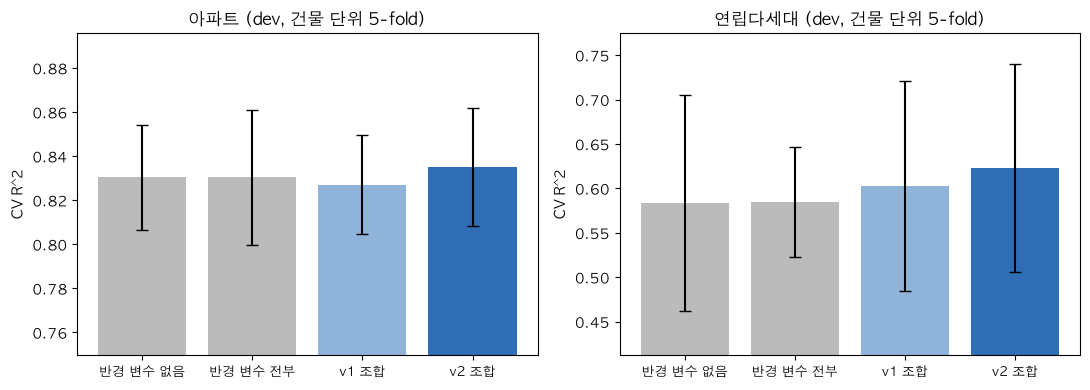

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, t in zip(axes, ['아파트', '연립다세대']):
    sub = radius_table[radius_table['주택유형'] == t]
    ax.bar(sub['설정'], sub['CV R^2'], yerr=sub['fold 표준편차'], capsize=4, color=['#bbbbbb', '#bbbbbb', '#8fb3d9', '#2f6db5'])
    lo = (sub['CV R^2'] - sub['fold 표준편차']).min()
    ax.set_ylim(max(0, lo - 0.05), min(1, sub['CV R^2'].max() + sub['fold 표준편차'].max() + 0.03))
    ax.set_title(f'{t} (dev, 건물 단위 5-fold)')
    ax.set_ylabel('CV R^2')
    ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.savefig('images/02_radius.png', dpi=120)
plt.show()

-> 반경 조합을 다시 고르면 아파트 0.827 -> 0.835, 연립다세대 0.602 -> 0.623으로 조금 좋아지긴 함  
그런데 막대 위 검은 선(fold별 표준편차)보다 차이가 작음. 반경을 아예 안 넣어도 아파트는 거의 같음  
-> 반경을 어떻게 고르냐보다 **데이터(중복, 좌표)랑 검증 방식**이 훨씬 큰 차이를 만들었음  
일단 dev에서 제일 좋았던 v2 조합을 쓰고, 연립다세대는 fold마다 R^2가 크게 흔들려서(극단적으로 비싼 몇 건 때문) 03에서는 오차율도 같이 봄

In [14]:
with open('data/v2_features.json', 'w', encoding='utf-8') as f:
    json.dump({'기본변수리스트': 기본변수리스트, '아파트': best_apt, '연립다세대': best_vil}, f, ensure_ascii=False, indent=2)
print(best_apt)
print(best_vil)

['병원_3km내_개수', '500m_이내_역_개수', '식당_1km내_개수', '공원_800m_이내_개수', '파출소/지구대_1km내_개수', '대학_1km내_개수']
['병원_1km내_개수', '1km_이내_역_개수', '식당_1km내_개수', '공원_800m_이내_개수', '파출소/지구대_0.5km내_개수', '대학_2km내_개수']
